## Student Performance Indicator


### Import required data and Packages

### Import csv data as Pandas dataframe

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

Matplotlib is building the font cache; this may take a moment.


In [2]:
df=pd.read_csv("StudentsPerformance.csv")

In [ ]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
df.shape

(1000, 8)

In [5]:
df.isna().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

#### There is no missing value in the dataset


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [8]:
df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

In [9]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [10]:
print("categories in 'gender'variable:   ",end=" ")
print(df['gender'].unique())

print("categories in 'race/ethnicity'variable:   ",end=" ")
print(df['race/ethnicity'].unique())

print("categories in 'parental level of education'variable:   ",end=" ")
print(df['parental level of education'].unique())

print("categories in 'lunch'variable:   ",end=" ")
print(df['lunch'].unique())

print("categories in 'test preparation course'variable:   ",end=" ")
print(df['test preparation course'].unique())

categories in 'gender'variable:    <StringArray>
['female', 'male']
Length: 2, dtype: str
categories in 'race/ethnicity'variable:    <StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str
categories in 'parental level of education'variable:    <StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str
categories in 'lunch'variable:    <StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str
categories in 'test preparation course'variable:    <StringArray>
['none', 'completed']
Length: 2, dtype: str


In [11]:
##define numerical and categorical features
cat_features=df.select_dtypes(include='object').columns.tolist()
num_features=df.select_dtypes(exclude='object').columns.tolist()
print('no. of numeric feature',len(num_features),num_features)
print('no. of categorical feature',len(cat_features),cat_features)

no. of numeric feature 3 ['math score', 'reading score', 'writing score']
no. of categorical feature 5 ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


In [12]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


### Adding columns for "Total Score" and "Average"

In [13]:
df['total score']=df['math score']+df['reading score']+df['writing score']
df['avg score']=df['total score']/3
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total score,avg score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


### Histogram and Kde

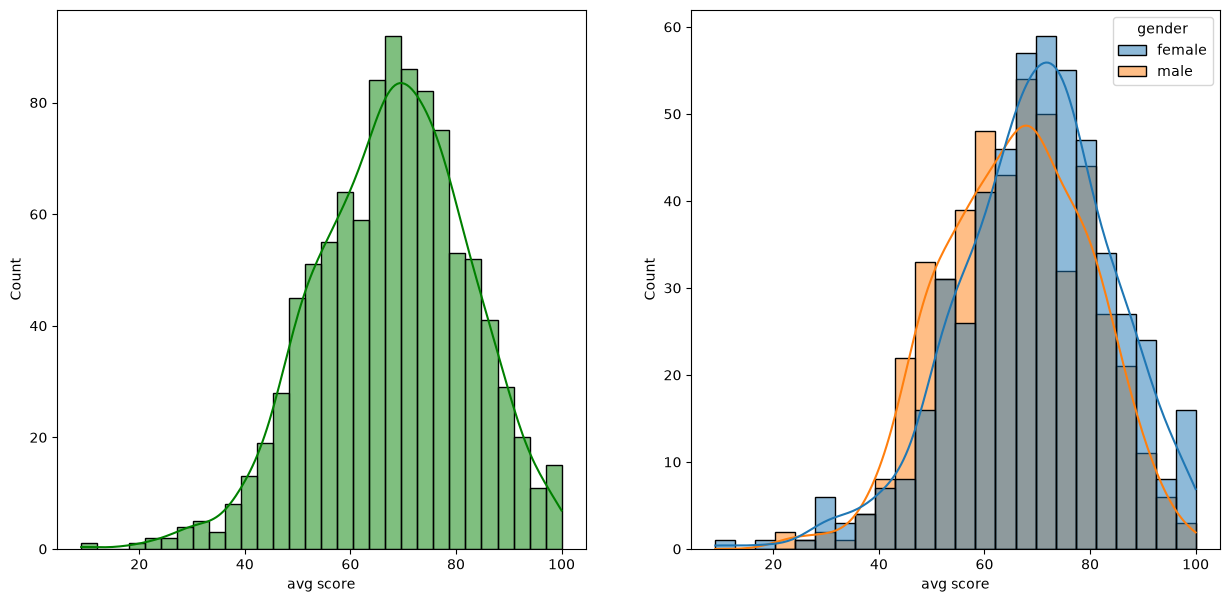

In [14]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
sns.histplot(data=df, x='avg score', bins=30, kde=True, color='g', ax=axs[0])

sns.histplot(data=df, x='avg score', kde=True, hue='gender', ax=axs[1])

plt.show()

<Axes: xlabel='total score', ylabel='Count'>

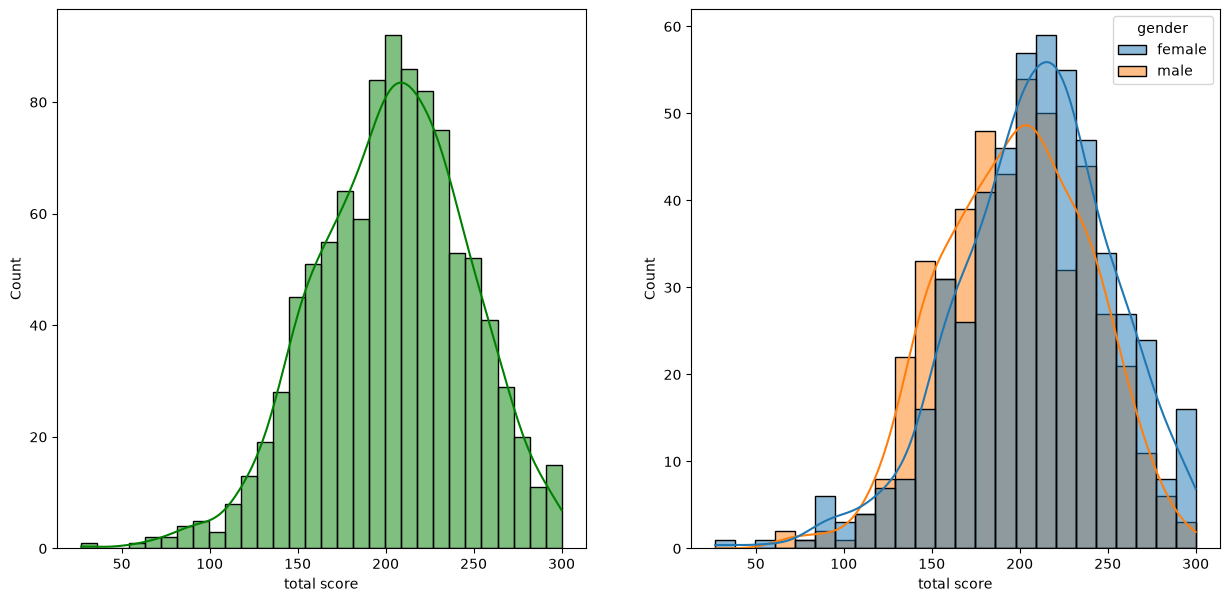

In [15]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
sns.histplot(data=df, x='total score', bins=30, kde=True, color='g', ax=axs[0])

sns.histplot(data=df, x='total score', kde=True, hue='gender', ax=axs[1])

<Axes: xlabel='avg score', ylabel='Count'>

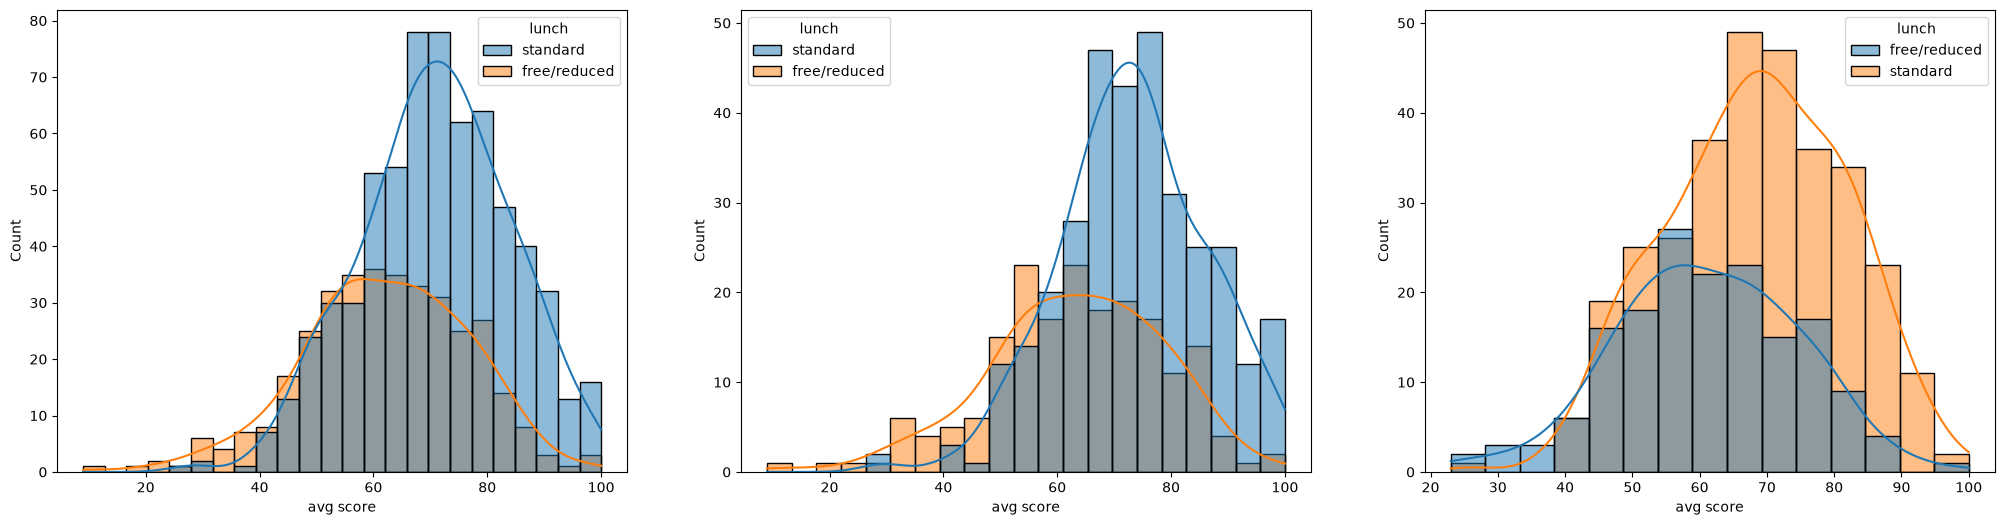

In [17]:
fig, axs = plt.subplots(1, 3, figsize=(25, 6))
sns.histplot(data=df, x='avg score',kde=True, color='g',hue='lunch', ax=axs[0])
sns.histplot(data=df[df.gender=='female'], x='avg score', kde=True, hue='lunch', ax=axs[1])
sns.histplot(data=df[df.gender=='male'], x='avg score', kde=True, hue='lunch', ax=axs[2])